# Laboratorio 3 - Deep Learning

## Reconocimiento del alfabeto ASL

**CC3084 - Data Science**  
**Integrantes:** Milton Polanco y Osman de León  
**Semestre II - 2026**

# 1. Introducción

En este laboratorio se construye un prototipo para clasificar imágenes de manos en las 29 clases del conjunto **ASL Alphabet**: las letras A-Z y las acciones `del`, `nothing` y `space`. El trabajo incluye análisis exploratorio, preprocesamiento, dos arquitecturas convolucionales, una red completamente conectada y un modelo clásico.

La comparación se hace con la misma submuestra y la misma división de datos. Esta decisión es importante: si cada modelo viera imágenes distintas, una diferencia de exactitud podría deberse a los datos y no al algoritmo.

La fuente original es [ASL Alphabet de Kaggle](https://www.kaggle.com/datasets/grassknoted/asl-alphabet). Para evitar guardar 1.1 GB en Git, el proyecto descarga una copia desde Google Drive cuando el conjunto no existe localmente.

## 1.1 Objetivos

- Describir la estructura, balance y variabilidad visual del conjunto de datos.
- Construir una división reproducible de entrenamiento, validación y prueba.
- Comparar modelos de distinta complejidad usando las mismas métricas.
- Estudiar el efecto de *image augmentation* sin aplicar transformaciones que alteren la seña.
- Analizar los límites del prototipo para un uso real de accesibilidad.

# 2. Configuración y reproducibilidad

In [13]:
import gc
import random
import re
import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
tf.get_logger().setLevel("ERROR")
from PIL import Image
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

# Permite ejecutar el notebook desde la raíz o desde notebooks/.
PROJECT_ROOT = next(
    candidate
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "src" / "download_dataset.py").exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.download_dataset import ensure_dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("colorblind")
print("TensorFlow:", tf.__version__)
print("Proyecto:", PROJECT_ROOT.name)

TensorFlow: 2.21.0
Proyecto: Lab-DeepLearning


In [14]:
DATASET_PATH = ensure_dataset()
TRAIN_PATH = DATASET_PATH / "train"
if not TRAIN_PATH.exists():
    TRAIN_PATH = DATASET_PATH / "asl_alphabet_train"
OFFICIAL_TEST_PATH = DATASET_PATH / "test"

if not TRAIN_PATH.exists():
    raise FileNotFoundError("No se encontró la carpeta de entrenamiento.")

CLASSES = sorted(folder.name for folder in TRAIN_PATH.iterdir() if folder.is_dir())
NUM_CLASSES = len(CLASSES)
CLASS_TO_ID = {name: idx for idx, name in enumerate(CLASSES)}

print("Entrenamiento:", TRAIN_PATH.relative_to(PROJECT_ROOT))
print("Prueba oficial:", OFFICIAL_TEST_PATH.relative_to(PROJECT_ROOT))
print(f"Clases ({NUM_CLASSES}):", CLASSES)

Dataset encontrado.

Entrenamiento: dataset\asl_alphabet_train
Prueba oficial: dataset\test
Clases (29): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


# 3. Análisis exploratorio

El análisis parte de preguntas concretas: ¿cuántas clases hay?, ¿están balanceadas?, ¿todas las imágenes tienen el mismo formato?, ¿qué cambia dentro de una clase? y ¿qué pares de letras son visualmente difíciles de separar?

## 3.1 ¿El conjunto está balanceado?

,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
clase,A,B,C,D,E,F,G,H,I,J,...,T,U,V,W,X,Y,Z,del,nothing,space
imagenes,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,...,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000


Total: 87,000 imágenes
Mínimo por clase: 3000
Máximo por clase: 3000


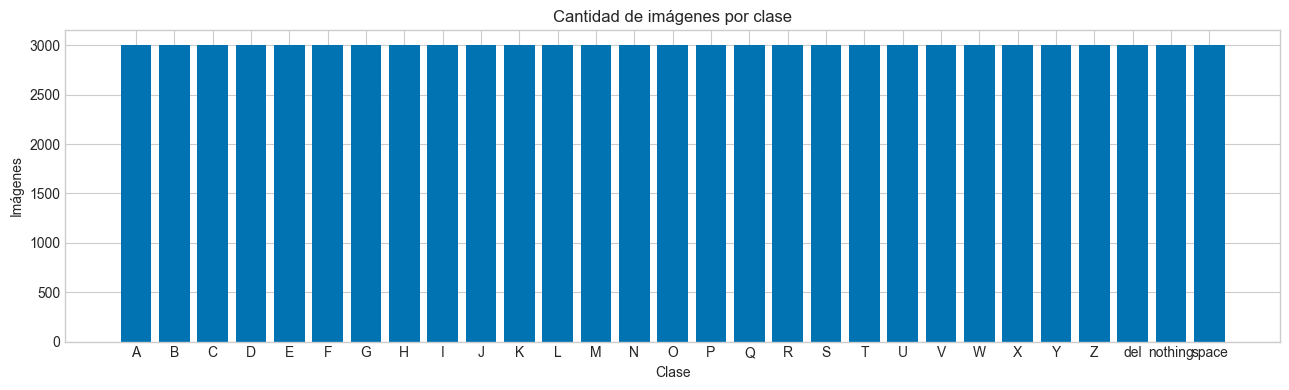

In [15]:
image_extensions = {".jpg", ".jpeg", ".png"}
dataset_rows = []
for class_name in CLASSES:
    files = [p for p in (TRAIN_PATH / class_name).iterdir()
             if p.suffix.lower() in image_extensions]
    dataset_rows.append({"clase": class_name, "imagenes": len(files)})

dataset_df = pd.DataFrame(dataset_rows)
display(dataset_df.T)
print(f"Total: {dataset_df['imagenes'].sum():,} imágenes")
print("Mínimo por clase:", dataset_df["imagenes"].min())
print("Máximo por clase:", dataset_df["imagenes"].max())

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(dataset_df["clase"], dataset_df["imagenes"])
ax.set(title="Cantidad de imágenes por clase", xlabel="Clase", ylabel="Imágenes")
plt.tight_layout()
plt.show()

Todas las clases tienen la misma cantidad de archivos. Por lo tanto, el conjunto está balanceado por **cantidad**, aunque esto no implica que sea representativo de la variedad de personas y condiciones que existirían en una aplicación real.

## 3.2 ¿Qué resolución, formato y color tienen las imágenes?

In [16]:
property_rows = []
for class_name in CLASSES:
    sample_paths = sorted((TRAIN_PATH / class_name).glob("*.jpg"))[:10]
    for path in sample_paths:
        with Image.open(path) as image:
            property_rows.append({
                "clase": class_name,
                "formato": image.format,
                "modo": image.mode,
                "ancho": image.width,
                "alto": image.height,
            })

properties_df = pd.DataFrame(property_rows)
display(properties_df.value_counts(["formato", "modo", "ancho", "alto"]).rename("conteo").to_frame())

,,,,conteo
formato,modo,ancho,alto,
JPEG,RGB,200,200,290


La revisión de 10 archivos por clase confirma el formato JPEG, tres canales RGB y resolución de 200 x 200 píxeles. La homogeneidad evita tener que corregir tamaños o modos de color diferentes antes de formar los lotes.

## 3.3 Ejemplos de distintas clases y variabilidad interna

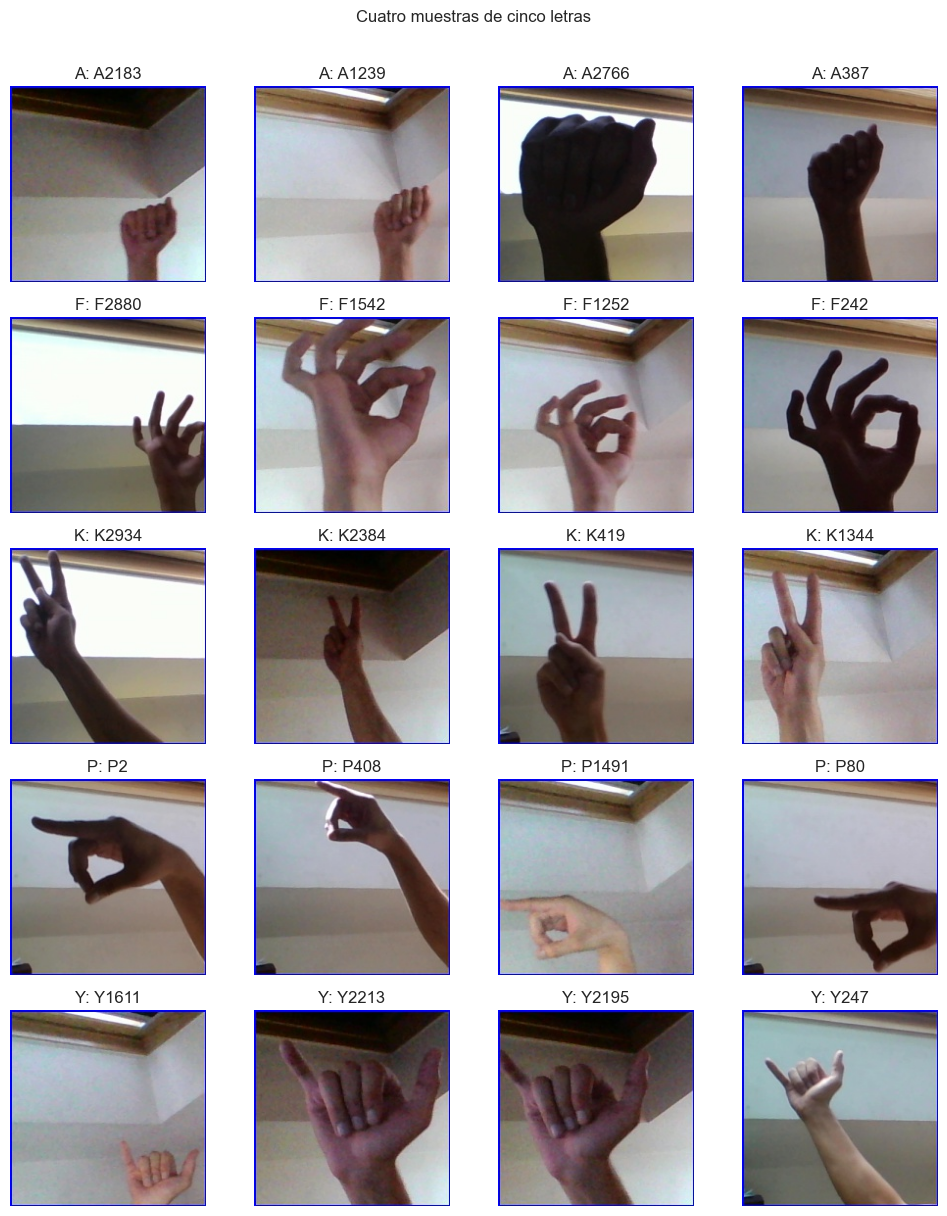

In [17]:
rng = np.random.default_rng(SEED)
example_classes = ["A", "F", "K", "P", "Y"]
fig, axes = plt.subplots(len(example_classes), 4, figsize=(10, 12))

for row, class_name in enumerate(example_classes):
    paths = sorted((TRAIN_PATH / class_name).glob("*.jpg"))
    chosen = rng.choice(paths, size=4, replace=False)
    for col, path in enumerate(chosen):
        axes[row, col].imshow(Image.open(path))
        axes[row, col].set_title(f"{class_name}: {path.stem}")
        axes[row, col].axis("off")

plt.suptitle("Cuatro muestras de cinco letras", y=1.01)
plt.tight_layout()
plt.show()

Dentro de una misma clase cambia ligeramente la posición, escala y orientación de la mano. Sin embargo, el fondo y la forma de iluminación son bastante constantes. El modelo podría aprender parte de ese entorno controlado, además de la forma de la mano; por eso una exactitud alta dentro del dataset no garantiza el mismo resultado con una cámara doméstica.

## 3.4 ¿Qué letras se parecen entre sí?

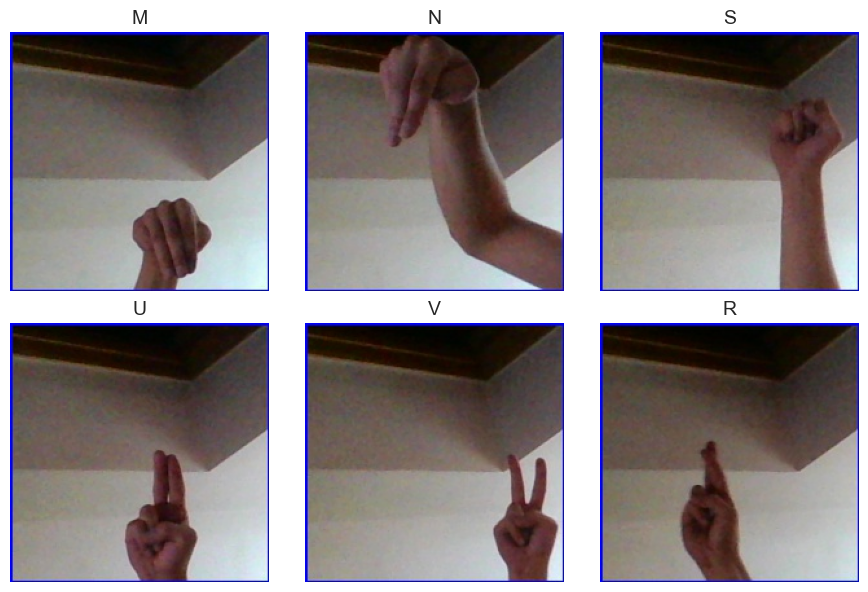

In [18]:
similar_groups = [["M", "N", "S"], ["U", "V", "R"]]
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for row, group in enumerate(similar_groups):
    for col, class_name in enumerate(group):
        paths = sorted((TRAIN_PATH / class_name).glob("*.jpg"))
        path = paths[len(paths) // 2]
        axes[row, col].imshow(Image.open(path))
        axes[row, col].set_title(class_name, fontsize=14)
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()

En **M/N/S** la mano permanece cerrada y la diferencia depende de la posición del pulgar y de cuántos dedos lo cubren. En **U/V/R** la información clave está en la separación o cruce de dos dedos. Son detalles locales y pequeños, por lo que reducir demasiado la resolución o capturar la mano con un ángulo distinto puede aumentar las confusiones. La matriz de confusión permitirá comprobar si estos pares también son difíciles para el modelo.

## 3.5 Brillo y contraste por clase

,brillo_promedio,contraste
clase,,
A,121.500000,61.500000
B,130.699997,63.299999
C,134.100006,59.900002
D,133.600006,61.299999
E,123.599998,64.800003
F,128.199997,60.099998
G,111.199997,53.200001
H,123.699997,58.799999
I,124.599998,58.500000


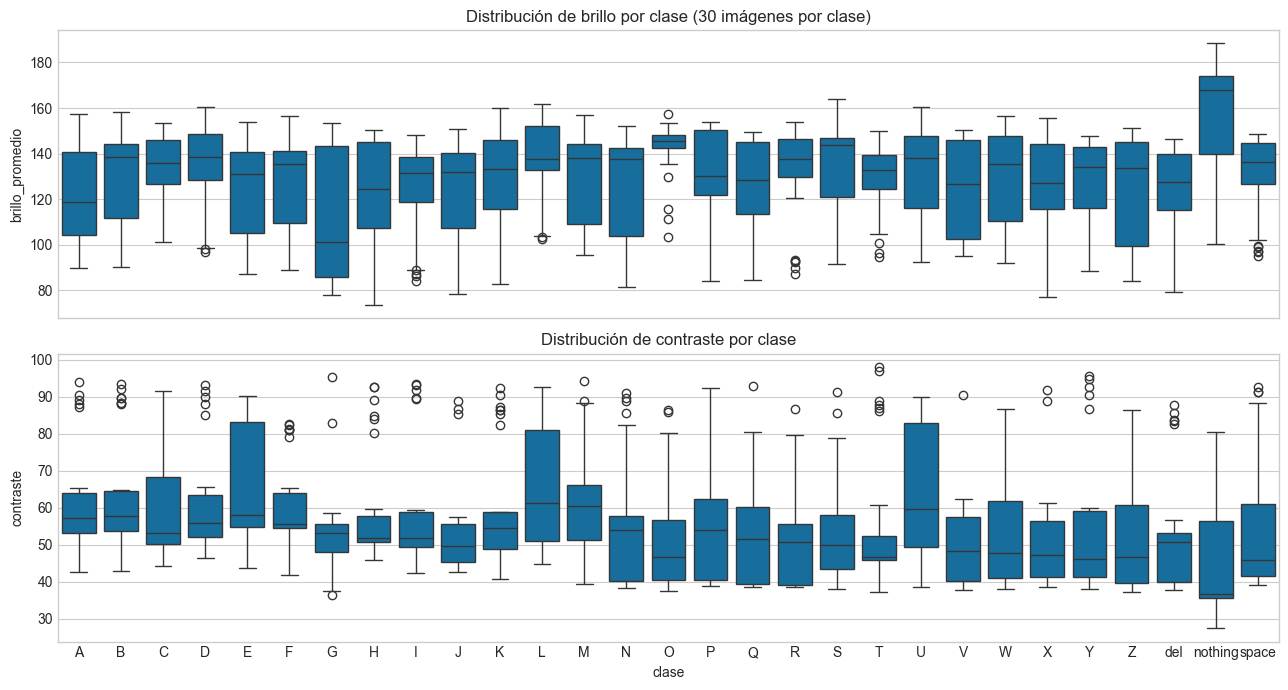

In [19]:
visual_rows = []
rng = np.random.default_rng(SEED)
for class_name in CLASSES:
    paths = sorted((TRAIN_PATH / class_name).glob("*.jpg"))
    for path in rng.choice(paths, size=30, replace=False):
        gray = np.asarray(Image.open(path).convert("L"), dtype=np.float32)
        visual_rows.append({
            "clase": class_name,
            "brillo_promedio": gray.mean(),
            "contraste": gray.std(),
        })

visual_df = pd.DataFrame(visual_rows)
display(visual_df.groupby("clase")[["brillo_promedio", "contraste"]].mean().round(1))

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
sns.boxplot(data=visual_df, x="clase", y="brillo_promedio", ax=axes[0])
sns.boxplot(data=visual_df, x="clase", y="contraste", ax=axes[1])
axes[0].set_title("Distribución de brillo por clase (30 imágenes por clase)")
axes[1].set_title("Distribución de contraste por clase")
plt.tight_layout()
plt.show()

Este cruce sirve para detectar si alguna etiqueta está asociada accidentalmente con una condición de iluminación. Si las cajas de una clase quedaran muy separadas del resto, un clasificador podría aprovechar el brillo como atajo. Las distribuciones se traslapan, pero siguen reflejando un ambiente más controlado que el esperado en producción.

# 4. División y preprocesamiento

## 4.1 Submuestra y división 70/15/15

Se usan **500 imágenes por clase**, el límite inferior del rango sugerido en el enunciado. Esto produce 14,500 imágenes y reduce el costo del laboratorio sin cambiar el balance. Para cada clase se barajan los archivos con semilla 42 y luego se asignan 350 a entrenamiento, 75 a validación y 75 a prueba. La carpeta de prueba oficial no se usa para ajustar modelos porque solo contiene una imagen por clase y no incluye `del`.

In [20]:
SAMPLES_PER_CLASS = 500
TRAIN_PER_CLASS = 350
VALIDATION_PER_CLASS = 75
TEST_PER_CLASS = 75

split_rows = []
rng = np.random.default_rng(SEED)
for class_name in CLASSES:
    files = np.array(sorted((TRAIN_PATH / class_name).glob("*.jpg")), dtype=object)
    if len(files) < SAMPLES_PER_CLASS:
        raise ValueError(f"{class_name} solo tiene {len(files)} imágenes")
    selected = rng.choice(files, size=SAMPLES_PER_CLASS, replace=False)
    rng.shuffle(selected)
    boundaries = {
        "train": selected[:TRAIN_PER_CLASS],
        "validation": selected[TRAIN_PER_CLASS:TRAIN_PER_CLASS + VALIDATION_PER_CLASS],
        "test": selected[TRAIN_PER_CLASS + VALIDATION_PER_CLASS:],
    }
    for split_name, paths in boundaries.items():
        split_rows.extend({
            "path": str(path),
            "class_name": class_name,
            "label": CLASS_TO_ID[class_name],
            "split": split_name,
        } for path in paths)

split_df = pd.DataFrame(split_rows)
split_summary = pd.crosstab(split_df["class_name"], split_df["split"])
display(split_summary)
print(split_df["split"].value_counts())

assert split_df["path"].nunique() == len(split_df)
assert (split_summary["train"] == TRAIN_PER_CLASS).all()
assert (split_summary["validation"] == VALIDATION_PER_CLASS).all()
assert (split_summary["test"] == TEST_PER_CLASS).all()

split,test,train,validation
class_name,,,
A,75,350,75
B,75,350,75
C,75,350,75
D,75,350,75
E,75,350,75
F,75,350,75
G,75,350,75
H,75,350,75
I,75,350,75


split
train         10150
validation     2175
test           2175
Name: count, dtype: int64


La separación es estratificada: cada conjunto conserva exactamente las 29 clases en la misma proporción. Una limitación es que el dataset no identifica persona ni sesión de captura; fotografías consecutivas podrían terminar en particiones diferentes y parecerse mucho. Para una evaluación de producto sería preferible dividir por persona o sesión, dato que aquí no está disponible.

## 4.2 Redimensionamiento, normalización y lotes

In [21]:
IMAGE_SIZE = (64, 64)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_rgb_image(path, label):
    data = tf.io.read_file(path)
    image = tf.io.decode_jpeg(data, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def make_dataset(frame, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (frame["path"].to_numpy(), frame["label"].to_numpy())
    )
    ds = ds.map(load_rgb_image, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()
    if training:
        ds = ds.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_frame = split_df.query("split == 'train'").reset_index(drop=True)
validation_frame = split_df.query("split == 'validation'").reset_index(drop=True)
test_frame = split_df.query("split == 'test'").reset_index(drop=True)

train_ds = make_dataset(train_frame, training=True)
validation_ds = make_dataset(validation_frame)
test_ds = make_dataset(test_frame)

images, labels = next(iter(train_ds))
print("Forma de un lote:", images.shape, labels.shape)
print("Rango normalizado:", float(tf.reduce_min(images)), float(tf.reduce_max(images)))

Forma de un lote: (32, 64, 64, 3) (32,)
Rango normalizado: 0.0 1.0


Las imágenes bajan de 200 x 200 a 64 x 64 píxeles mediante interpolación bilineal y los canales RGB se mantienen. Luego, los valores se dividen entre 255 para pasar de enteros en [0, 255] a números en [0, 1]. No se aplican filtros de borde ni conversión general a grises porque el color puede ayudar a separar mano y fondo. El modelo clásico sí usa una copia en escala de grises y 32 x 32 para limitar el número de variables.

## 4.3 Aumento de datos válido para señas

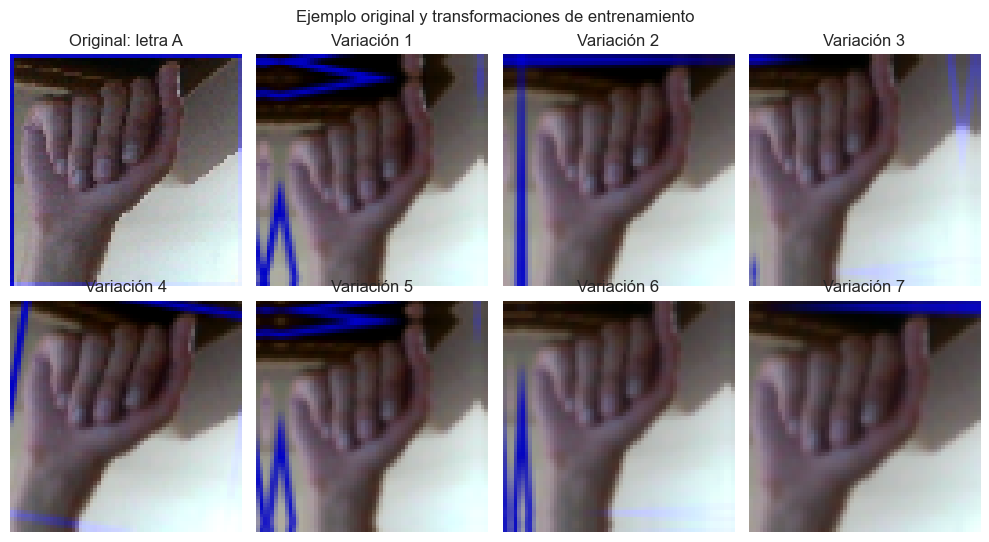

In [22]:
def make_augmentation():
    return tf.keras.Sequential([
        tf.keras.layers.RandomRotation(0.04),
        tf.keras.layers.RandomTranslation(0.08, 0.08),
        tf.keras.layers.RandomZoom(0.10),
        tf.keras.layers.RandomContrast(0.15),
    ], name="augmentation")

# Se usa una letra conocida para que la transformación sea fácil de comparar.
sample_path = TRAIN_PATH / "A" / "A2500.jpg"
if not sample_path.exists():
    sample_path = sorted((TRAIN_PATH / "A").glob("*.jpg"))[0]

preview_image = tf.keras.utils.load_img(sample_path, target_size=IMAGE_SIZE)
preview_array = tf.keras.utils.img_to_array(preview_image) / 255.0
sample = tf.expand_dims(preview_array, axis=0)
augmentation_preview = make_augmentation()

fig, axes = plt.subplots(2, 4, figsize=(10, 5.5))
axes = axes.ravel()
axes[0].imshow(preview_array)
axes[0].set_title("Original: letra A")
axes[0].axis("off")

for number, ax in enumerate(axes[1:], start=1):
    augmented = augmentation_preview(sample, training=True)[0]
    ax.imshow(tf.clip_by_value(augmented, 0, 1))
    ax.set_title(f"Variación {number}")
    ax.axis("off")

plt.suptitle("Ejemplo original y transformaciones de entrenamiento")
plt.tight_layout()
plt.show()

Se permiten rotaciones pequeñas, traslaciones, acercamientos y cambios moderados de contraste porque imitan variaciones de cámara sin modificar la configuración básica de los dedos. **No se usa `RandomFlip`**: reflejar una mano cambia su lateralidad y puede producir una imagen que no corresponde a la misma ejecución de la seña. Tampoco se aceptan rotaciones grandes, recortes fuertes ni deformaciones, ya que podrían ocultar o cambiar el dedo que distingue una letra de otra.

El marco azul visible en algunas variaciones ya está presente en las imágenes originales de Kaggle; las transformaciones geométricas lo desplazan o reflejan hacia el interior. Esto es una limitación adicional del dataset, porque el modelo podría aprender elementos del borde y del fondo que no forman parte de la seña. En una siguiente versión convendría recortar ese marco de manera consistente antes de dividir y entrenar nuevamente los modelos.

# 5. Funciones de entrenamiento y evaluación

In [23]:
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
MODELS_DIR = ARTIFACTS_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

histories = {}
results = []
saved_models = {}
predictions = {}

y_validation = validation_frame["label"].to_numpy()
y_test = test_frame["label"].to_numpy()

def metric_row(name, family, params, y_val_pred, y_test_pred, seconds):
    predictions[name] = {
        "validation": y_val_pred,
        "test": y_test_pred,
    }
    return {
        "modelo": name,
        "familia": family,
        "parametros": params,
        "val_accuracy": accuracy_score(y_validation, y_val_pred),
        "val_precision_macro": precision_score(y_validation, y_val_pred, average="macro", zero_division=0),
        "val_recall_macro": recall_score(y_validation, y_val_pred, average="macro", zero_division=0),
        "val_f1_macro": f1_score(y_validation, y_val_pred, average="macro", zero_division=0),
        "test_accuracy": accuracy_score(y_test, y_test_pred),
        "test_f1_macro": f1_score(y_test, y_test_pred, average="macro", zero_division=0),
        "segundos": seconds,
    }

def fit_keras_experiment(name, family, model, params, epochs):
    start = time.perf_counter()
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=2, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=1, min_lr=1e-5
        ),
    ]
    history = model.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=2,
    )
    elapsed = time.perf_counter() - start
    histories[name] = history.history
    y_val_pred = model.predict(validation_ds, verbose=0).argmax(axis=1)
    y_test_pred = model.predict(test_ds, verbose=0).argmax(axis=1)
    path = MODELS_DIR / f"{name}.keras"
    model.save(path)
    saved_models[name] = {"kind": "keras", "path": path}
    row = metric_row(name, family, params, y_val_pred, y_test_pred, elapsed)
    results.append(row)
    print(pd.Series(row).drop(["parametros"]).to_string())
    del model
    gc.collect()
    tf.keras.backend.clear_session()

def plot_history(name):
    history = histories[name]
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].plot(history["loss"], label="entrenamiento")
    axes[0].plot(history["val_loss"], label="validación")
    axes[0].set(title=f"Pérdida - {name}", xlabel="Época")
    axes[1].plot(history["accuracy"], label="entrenamiento")
    axes[1].plot(history["val_accuracy"], label="validación")
    axes[1].set(title=f"Accuracy - {name}", xlabel="Época")
    for ax in axes:
        ax.legend()
    plt.tight_layout()
    plt.show()

def compile_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

Las métricas principales son `accuracy` y F1 macro. Como las clases están balanceadas, ambas deberían ser cercanas; F1 macro también obliga a que todas las clases tengan el mismo peso. Se conserva el modelo de la época con menor pérdida de validación mediante *early stopping*. El conjunto de prueba nunca se usa para actualizar pesos.

# 6. Modelos convolucionales sin aumento

## 6.1 CNN base

La primera red usa dos bloques convolución-*pooling* y una capa `GlobalAveragePooling2D`. Sirve como línea base de baja complejidad.

Model: "cnn_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │         1,885 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,437 (99.36 KB)

 Trainable params: 25,437 (99.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/7
318/318 - 18s - 56ms/step - accuracy: 0.0331 - loss: 3.3677 - val_accuracy: 0.0607 - val_loss: 3.3598 - learning_rate: 0.0010
Epoch 2/7
318/318 - 14s - 45ms/step - accuracy: 0.0655 - loss: 3.2620 - val_accuracy: 0.0956 - val_loss: 3.0841 - learning_rate: 0.0010
Epoch 3/7
318/318 - 15s - 46ms/step - accuracy: 0.1022 - loss: 3.0581 - val_accuracy: 0.1421 - val_loss: 2.9427 - learning_rate: 0.0010
Epoch 4/7
318/318 - 14s - 45ms/step - accuracy: 0.1274 - loss: 2.9083 - val_accuracy: 0.1651 - val_loss: 2.7343 - learning_rate: 0.0010
Epoch 5/7
318/318 - 9s - 30ms/step - accuracy: 0.1624 - loss: 2.7375 - val_accuracy: 0.1899 - val_loss: 2.5910 - learning_rate: 0.0010
Epoch 6/7
318/318 - 12s - 36ms/step - accuracy: 0.1784 - loss: 2.6324 - val_accuracy: 0.2133 - val_loss: 2.5387 - learning_rate: 0.0010
Epoch 7/7
318/318 - 17s - 52ms/step - accuracy: 0.1978 - loss: 2.5562 - val_accuracy: 0.2446 - val_loss: 2.4096 - learning_rate: 0.0010
modelo                   cnn_base
familia        

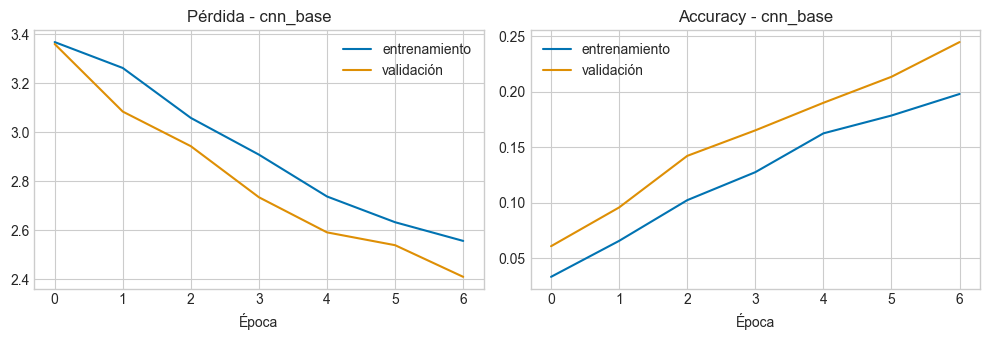

In [24]:
def build_cnn_base(use_augmentation=False):
    layers = [tf.keras.layers.Input(shape=(*IMAGE_SIZE, 3))]
    if use_augmentation:
        layers.append(make_augmentation())
    layers.extend([
        tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax"),
    ])
    return compile_model(tf.keras.Sequential(layers, name="cnn_base"))

cnn_base = build_cnn_base()
cnn_base.summary()
fit_keras_experiment(
    "cnn_base", "CNN", cnn_base,
    "filtros 32-64; dropout 0.25; sin augmentation", epochs=7
)
plot_history("cnn_base")

## 6.2 CNN de mayor capacidad

La segunda alternativa agrega un tercer nivel de filtros, convoluciones dobles, normalización por lotes y mayor regularización. La hipótesis es que podrá representar mejor diferencias pequeñas entre dedos, aunque también tendrá más costo y riesgo de sobreajuste.

Model: "cnn_improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,573 (627.24 KB)

 Trainable params: 160,125 (625.49 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/8
318/318 - 252s - 791ms/step - accuracy: 0.2959 - loss: 2.3850 - val_accuracy: 0.0345 - val_loss: 9.9578 - learning_rate: 8.0000e-04
Epoch 2/8
318/318 - 253s - 797ms/step - accuracy: 0.6350 - loss: 1.1152 - val_accuracy: 0.2294 - val_loss: 3.0225 - learning_rate: 8.0000e-04
Epoch 3/8
318/318 - 197s - 619ms/step - accuracy: 0.7987 - loss: 0.6226 - val_accuracy: 0.7798 - val_loss: 0.6221 - learning_rate: 8.0000e-04
Epoch 4/8
318/318 - 130s - 410ms/step - accuracy: 0.8843 - loss: 0.3597 - val_accuracy: 0.4690 - val_loss: 2.7945 - learning_rate: 8.0000e-04
Epoch 5/8
318/318 - 138s - 433ms/step - accuracy: 0.9531 - loss: 0.1739 - val_accuracy: 0.9678 - val_loss: 0.1180 - learning_rate: 4.0000e-04
Epoch 6/8
318/318 - 129s - 406ms/step - accuracy: 0.9645 - loss: 0.1345 - val_accuracy: 0.9320 - val_loss: 0.2002 - learning_rate: 4.0000e-04
Epoch 7/8
318/318 - 130s - 409ms/step - accuracy: 0.9787 - loss: 0.0917 - val_accuracy: 0.9844 - val_loss: 0.0668 - learning_rate: 2.0000e-04
Epoch 

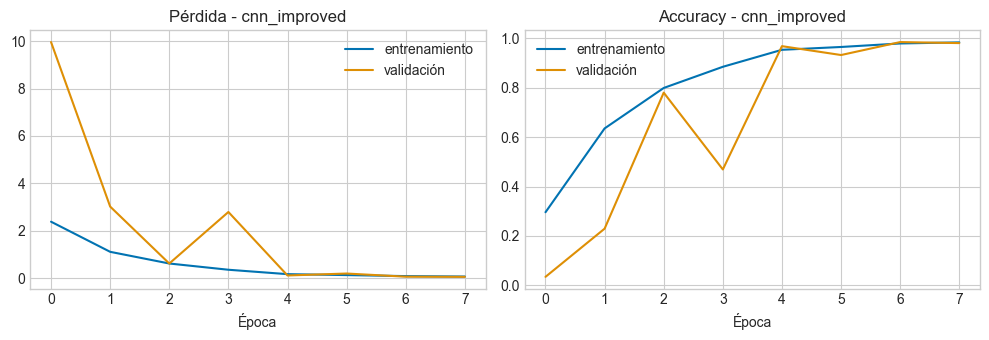

In [25]:
def build_cnn_improved(use_augmentation=False):
    inputs = tf.keras.Input(shape=(*IMAGE_SIZE, 3))
    x = make_augmentation()(inputs) if use_augmentation else inputs
    for filters in (32, 64):
        x = tf.keras.layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.40)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return compile_model(tf.keras.Model(inputs, outputs, name="cnn_improved"), 8e-4)

cnn_improved = build_cnn_improved()
cnn_improved.summary()
fit_keras_experiment(
    "cnn_improved", "CNN", cnn_improved,
    "bloques 32-64-128; batch normalization; dropout 0.40; sin augmentation", epochs=8
)
plot_history("cnn_improved")

# 7. Red neuronal completamente conectada

Una red densa aplana la imagen y pierde la estructura de vecindad entre píxeles. Para evitar una capa inicial excesivamente grande, ambas variantes hacen una reducción adicional a 32 x 32 antes de aplanar. Se prueban una configuración compacta y otra más ancha con normalización por lotes. Así se evalúa si aumentar parámetros compensa la falta de convoluciones.

Model: "fc_compact"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,085 (1.51 MB)

 Trainable params: 397,085 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 29)             │         1,885 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 806,045 (3.07 MB)

 Trainable params: 805,533 (3.07 MB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/15
318/318 - 13s - 40ms/step - accuracy: 0.0889 - loss: 3.3662 - val_accuracy: 0.1057 - val_loss: 3.1824 - learning_rate: 1.0000e-04
Epoch 2/15
318/318 - 9s - 29ms/step - accuracy: 0.1600 - loss: 2.9745 - val_accuracy: 0.1894 - val_loss: 2.8723 - learning_rate: 1.0000e-04
Epoch 3/15
318/318 - 8s - 24ms/step - accuracy: 0.1968 - loss: 2.7798 - val_accuracy: 0.2299 - val_loss: 2.6572 - learning_rate: 1.0000e-04
Epoch 4/15
318/318 - 8s - 25ms/step - accuracy: 0.2296 - loss: 2.6445 - val_accuracy: 0.2014 - val_loss: 2.6285 - learning_rate: 1.0000e-04
Epoch 5/15
318/318 - 11s - 35ms/step - accuracy: 0.2582 - loss: 2.5345 - val_accuracy: 0.2759 - val_loss: 2.4373 - learning_rate: 1.0000e-04
Epoch 6/15
318/318 - 9s - 29ms/step - accuracy: 0.2862 - loss: 2.4419 - val_accuracy: 0.2501 - val_loss: 2.4952 - learning_rate: 1.0000e-04
Epoch 7/15
318/318 - 4s - 14ms/step - accuracy: 0.3045 - loss: 2.3367 - val_accuracy: 0.3407 - val_loss: 2.2529 - learning_rate: 5.0000e-05
Epoch 8/15
318/318

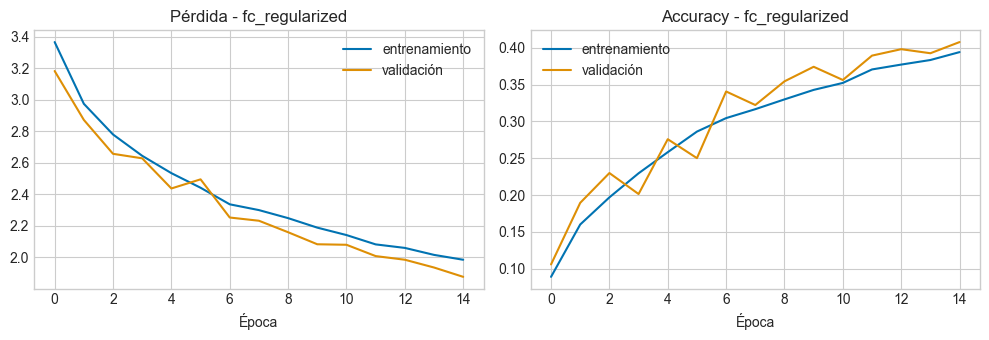

In [26]:
def build_fully_connected(variant="compact"):
    if variant == "compact":
        hidden = [
            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.Dropout(0.30),
        ]
    else:
        hidden = [
            tf.keras.layers.Dense(256, activation="relu"),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Dropout(0.50),
            tf.keras.layers.Dense(64, activation="relu"),
        ]
    return compile_model(tf.keras.Sequential([
        tf.keras.layers.Input(shape=(*IMAGE_SIZE, 3)),
        tf.keras.layers.Resizing(32, 32),
        tf.keras.layers.Flatten(),
        *hidden,
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax"),
    ], name=f"fc_{variant}"), learning_rate=1e-4)

fc_compact = build_fully_connected("compact")
fc_compact.summary()
fit_keras_experiment(
    "fc_compact", "Fully connected", fc_compact,
    "entrada 32x32; Dense 128; dropout 0.30; lr 1e-4", epochs=12
)

fc_regularized = build_fully_connected("regularized")
fc_regularized.summary()
fit_keras_experiment(
    "fc_regularized", "Fully connected", fc_regularized,
    "entrada 32x32; Dense 256-64; dropout 0.50; lr 1e-4", epochs=15
)
plot_history("fc_regularized")

### Resultado de la red densa

La variante compacta obtuvo F1 macro de prueba de **0.2506**. Al aumentar la capacidad, agregar normalización por lotes y mantener una tasa de aprendizaje de `1e-4`, la variante regularizada subió a **0.3866**. La prueba de parámetros sí produjo una mejora, pero ambas quedaron lejos de la CNN mejorada. Aplanar la imagen obliga a aprender por separado relaciones que una convolución comparte entre posiciones y, por eso, usa más parámetros sin aprovechar bien la estructura espacial.

# 8. Modelo clásico: Random Forest

Se seleccionó Random Forest porque puede modelar relaciones no lineales, admite clasificación multiclase sin cambios y ofrece una referencia que no depende de descenso de gradiente. Para que el costo sea razonable, las imágenes se convierten a escala de grises de 32 x 32, es decir, 1,024 variables por imagen. Se comparan dos profundidades y cantidades de árboles.

In [27]:
CLASSIC_SIZE = (32, 32)

def load_flat_grayscale(frame):
    x = np.empty((len(frame), CLASSIC_SIZE[0] * CLASSIC_SIZE[1]), dtype=np.float32)
    for idx, path in enumerate(frame["path"]):
        with Image.open(path) as image:
            x[idx] = np.asarray(
                image.convert("L").resize(CLASSIC_SIZE), dtype=np.float32
            ).ravel() / 255.0
    return x, frame["label"].to_numpy()

x_train_rf, y_train_rf = load_flat_grayscale(train_frame)
x_validation_rf, _ = load_flat_grayscale(validation_frame)
x_test_rf, _ = load_flat_grayscale(test_frame)
print(x_train_rf.shape, x_validation_rf.shape, x_test_rf.shape)

(10150, 1024) (2175, 1024) (2175, 1024)


In [28]:
rf_settings = {
    "rf_depth20": dict(n_estimators=100, max_depth=20, min_samples_leaf=2),
    "rf_unrestricted": dict(n_estimators=160, max_depth=None, min_samples_leaf=1),
}

for name, params in rf_settings.items():
    start = time.perf_counter()
    model = RandomForestClassifier(
        **params,
        random_state=SEED,
        n_jobs=-1,
        class_weight="balanced",
    )
    model.fit(x_train_rf, y_train_rf)
    elapsed = time.perf_counter() - start
    y_val_pred = model.predict(x_validation_rf)
    y_test_pred = model.predict(x_test_rf)
    path = MODELS_DIR / f"{name}.joblib"
    joblib.dump(model, path, compress=3)
    saved_models[name] = {"kind": "sklearn", "path": path}
    row = metric_row(name, "Random Forest", str(params), y_val_pred, y_test_pred, elapsed)
    results.append(row)
    print()
    print(pd.Series(row).drop(["parametros"]).to_string())
    del model
    gc.collect()


modelo                    rf_depth20
familia                Random Forest
val_accuracy                0.958161
val_precision_macro         0.959186
val_recall_macro            0.958161
val_f1_macro                0.958148
test_accuracy                0.96046
test_f1_macro               0.960401
segundos                    1.913962

modelo                 rf_unrestricted
familia                  Random Forest
val_accuracy                  0.961379
val_precision_macro           0.961911
val_recall_macro              0.961379
val_f1_macro                  0.961341
test_accuracy                 0.967816
test_f1_macro                 0.967767
segundos                      3.716329


# 9. Reentrenamiento con aumento de datos

Se vuelven a entrenar las dos CNN desde cero con las transformaciones definidas en la sección 4.3. La validación y la prueba permanecen sin alteraciones; aumentar esos conjuntos produciría una medición distinta de la imagen real y haría injusta la comparación.

Epoch 1/9
318/318 - 28s - 87ms/step - accuracy: 0.0348 - loss: 3.3677 - val_accuracy: 0.0382 - val_loss: 3.3568 - learning_rate: 0.0010
Epoch 2/9
318/318 - 23s - 72ms/step - accuracy: 0.0613 - loss: 3.2856 - val_accuracy: 0.0855 - val_loss: 3.1566 - learning_rate: 0.0010
Epoch 3/9
318/318 - 26s - 81ms/step - accuracy: 0.0821 - loss: 3.1584 - val_accuracy: 0.1062 - val_loss: 3.0664 - learning_rate: 0.0010
Epoch 4/9
318/318 - 37s - 115ms/step - accuracy: 0.1046 - loss: 3.0370 - val_accuracy: 0.1159 - val_loss: 2.9675 - learning_rate: 0.0010
Epoch 5/9
318/318 - 11s - 34ms/step - accuracy: 0.1425 - loss: 2.8804 - val_accuracy: 0.1669 - val_loss: 2.7307 - learning_rate: 0.0010
Epoch 6/9
318/318 - 10s - 33ms/step - accuracy: 0.1543 - loss: 2.7719 - val_accuracy: 0.1549 - val_loss: 2.7014 - learning_rate: 0.0010
Epoch 7/9
318/318 - 24s - 75ms/step - accuracy: 0.1704 - loss: 2.6829 - val_accuracy: 0.2051 - val_loss: 2.5241 - learning_rate: 0.0010
Epoch 8/9
318/318 - 42s - 132ms/step - accuracy

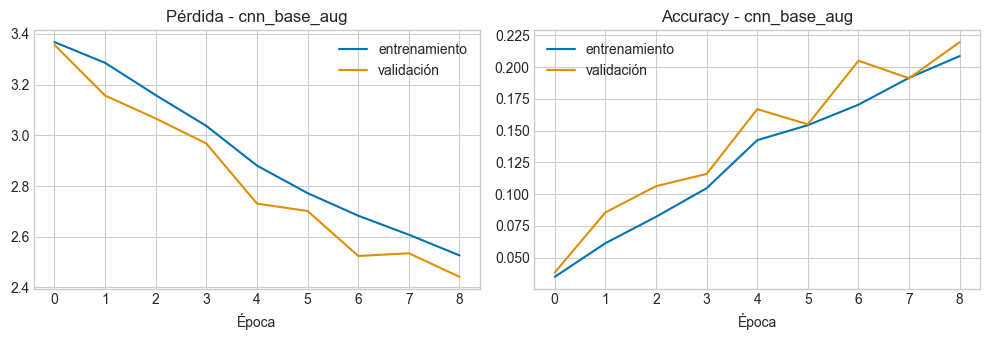

Epoch 1/9
318/318 - 271s - 854ms/step - accuracy: 0.2578 - loss: 2.5519 - val_accuracy: 0.0345 - val_loss: 9.8586 - learning_rate: 8.0000e-04
Epoch 2/9
318/318 - 277s - 871ms/step - accuracy: 0.5448 - loss: 1.4049 - val_accuracy: 0.5200 - val_loss: 1.4592 - learning_rate: 8.0000e-04
Epoch 3/9
318/318 - 179s - 563ms/step - accuracy: 0.7171 - loss: 0.8708 - val_accuracy: 0.7867 - val_loss: 0.6674 - learning_rate: 8.0000e-04
Epoch 4/9
318/318 - 194s - 610ms/step - accuracy: 0.8049 - loss: 0.5900 - val_accuracy: 0.8372 - val_loss: 0.5075 - learning_rate: 8.0000e-04
Epoch 5/9
318/318 - 164s - 517ms/step - accuracy: 0.8649 - loss: 0.4190 - val_accuracy: 0.6952 - val_loss: 0.9973 - learning_rate: 8.0000e-04
Epoch 6/9
318/318 - 170s - 534ms/step - accuracy: 0.9151 - loss: 0.2791 - val_accuracy: 0.8538 - val_loss: 0.4465 - learning_rate: 4.0000e-04
Epoch 7/9
318/318 - 274s - 862ms/step - accuracy: 0.9351 - loss: 0.2170 - val_accuracy: 0.9563 - val_loss: 0.1463 - learning_rate: 4.0000e-04
Epoch 

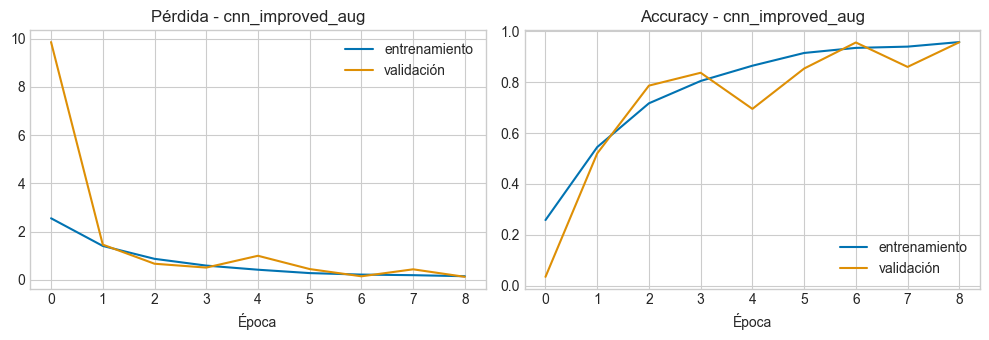

In [29]:
cnn_base_aug = build_cnn_base(use_augmentation=True)
fit_keras_experiment(
    "cnn_base_aug", "CNN + augmentation", cnn_base_aug,
    "filtros 32-64; dropout 0.25; rotación/traslación/zoom/contraste", epochs=9
)
plot_history("cnn_base_aug")

cnn_improved_aug = build_cnn_improved(use_augmentation=True)
fit_keras_experiment(
    "cnn_improved_aug", "CNN + augmentation", cnn_improved_aug,
    "bloques 32-64-128; BN; dropout 0.40; rotación/traslación/zoom/contraste", epochs=9
)
plot_history("cnn_improved_aug")

In [30]:
results_df = pd.DataFrame(results).sort_values("val_f1_macro", ascending=False).reset_index(drop=True)
metric_columns = [
    "modelo", "familia", "val_accuracy", "val_precision_macro",
    "val_recall_macro", "val_f1_macro", "test_accuracy", "test_f1_macro", "segundos"
]
display(results_df[metric_columns].style.format({
    "val_accuracy": "{:.4f}",
    "val_precision_macro": "{:.4f}",
    "val_recall_macro": "{:.4f}",
    "val_f1_macro": "{:.4f}",
    "test_accuracy": "{:.4f}",
    "test_f1_macro": "{:.4f}",
    "segundos": "{:.1f}",
}))

augmentation_effect = []
for original, augmented in [("cnn_base", "cnn_base_aug"), ("cnn_improved", "cnn_improved_aug")]:
    before = results_df.set_index("modelo").loc[original]
    after = results_df.set_index("modelo").loc[augmented]
    augmentation_effect.append({
        "arquitectura": original,
        "delta_val_f1": after["val_f1_macro"] - before["val_f1_macro"],
        "delta_test_f1": after["test_f1_macro"] - before["test_f1_macro"],
    })
display(pd.DataFrame(augmentation_effect).style.format({
    "delta_val_f1": "{:+.4f}", "delta_test_f1": "{:+.4f}"
}))

,modelo,familia,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,test_accuracy,test_f1_macro,segundos
0,cnn_improved,CNN,0.9802,0.9832,0.9802,0.9807,0.9798,0.9800,1514.2
1,rf_unrestricted,Random Forest,0.9614,0.9619,0.9614,0.9613,0.9678,0.9678,3.7
2,rf_depth20,Random Forest,0.9582,0.9592,0.9582,0.9581,0.9605,0.9604,1.9
3,cnn_improved_aug,CNN + augmentation,0.9572,0.9603,0.9572,0.9574,0.9605,0.9605,2022.9
4,fc_regularized,Fully connected,0.4078,0.4412,0.4078,0.3810,0.4216,0.3866,127.9
5,fc_compact,Fully connected,0.2634,0.3040,0.2634,0.2338,0.2800,0.2506,31.6
6,cnn_base,CNN,0.2446,0.2196,0.2446,0.2043,0.2497,0.2099,102.5
7,cnn_base_aug,CNN + augmentation,0.2198,0.2266,0.2198,0.1774,0.2175,0.1767,227.8


,arquitectura,delta_val_f1,delta_test_f1
0,cnn_base,-0.0268,-0.0332
1,cnn_improved,-0.0233,-0.0195


### Comparación de modelos y efecto del aumento

La **CNN mejorada sin augmentation** encabezó la validación con F1 macro de **0.9807** y obtuvo **0.9800** en prueba. Random Forest quedó segundo entre las familias sin aumento, con F1 de prueba de **0.9678**, y tardó 3.7 segundos en ajustar sus árboles; es una línea base muy competitiva para este conjunto controlado. La red densa regularizada llegó a 0.3866 y la CNN base a 0.2099, por lo que añadir capas sin una arquitectura adecuada no fue suficiente.

El aumento no mejoró en este presupuesto de entrenamiento. Frente a la misma arquitectura, redujo el F1 de validación en **0.0268** para la CNN base y **0.0233** para la CNN mejorada. Las transformaciones vuelven el problema más difícil y las curvas muestran que la red aumentada aún estaba aprendiendo. El resultado no invalida las transformaciones escogidas, pero sí indica que no conviene seleccionar el modelo aumentado con estas épocas. Se mantiene la comparación negativa porque también es un hallazgo del experimento.

# 10. Selección y análisis de errores

Modelo seleccionado por F1 macro de validación: cnn_improved
modelo                 cnn_improved
familia                         CNN
val_accuracy                0.98023
val_precision_macro        0.983238
val_recall_macro            0.98023
val_f1_macro               0.980721
test_accuracy               0.97977
test_f1_macro              0.980024
segundos                1514.200977


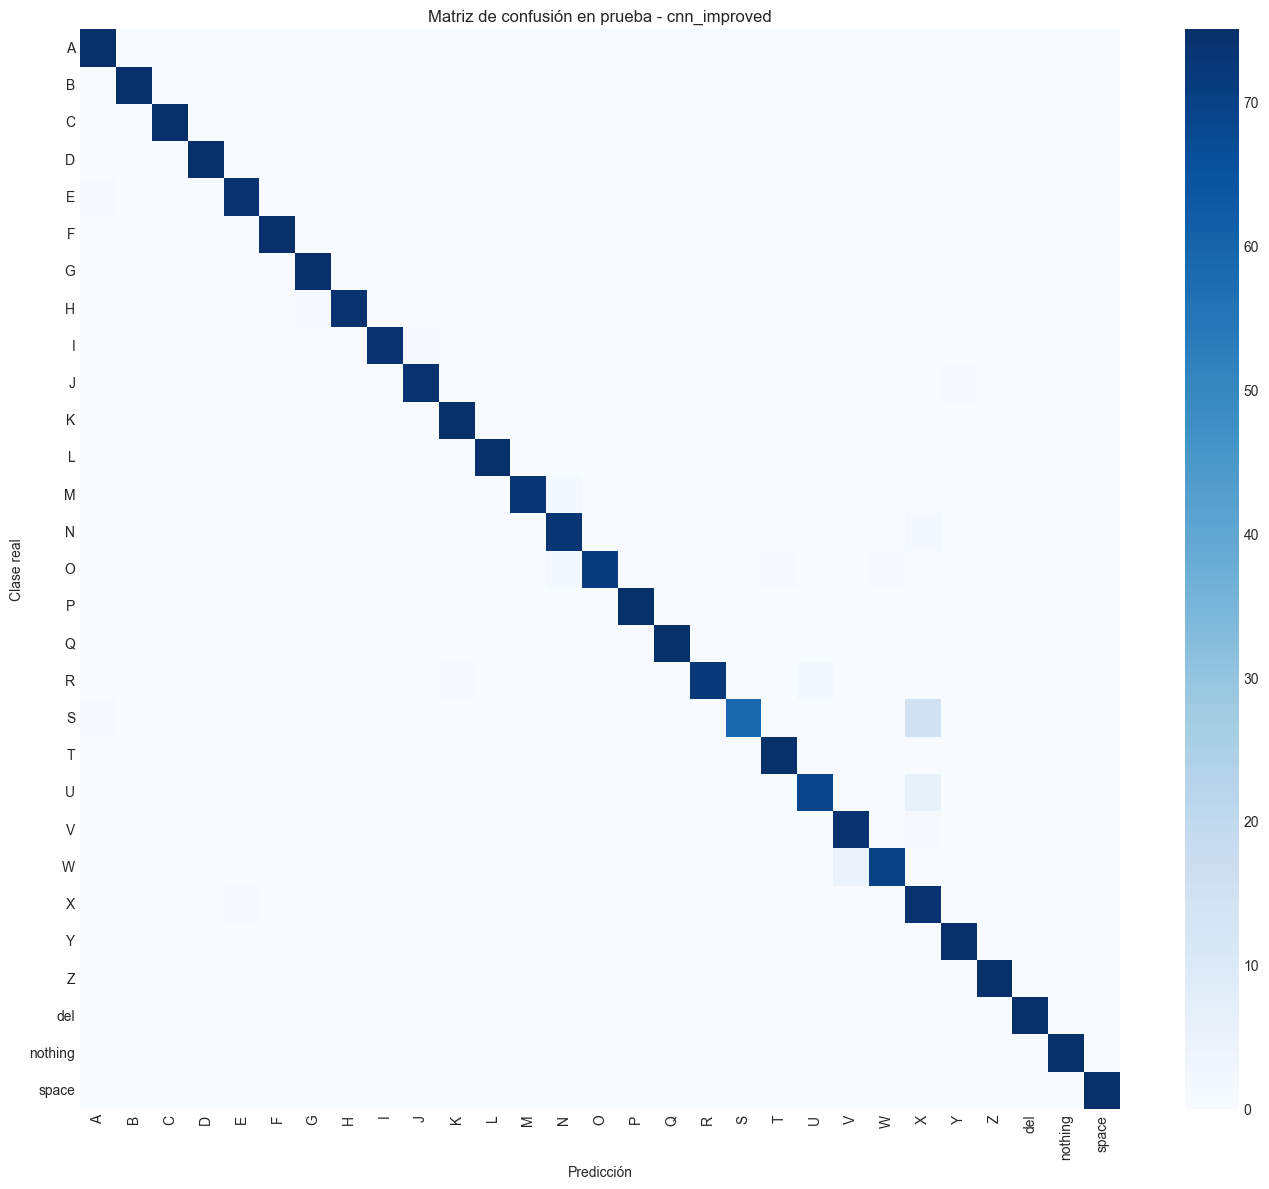

,precision,recall,f1-score,support
A,0.974,1.000,0.987,75.00
B,1.000,1.000,1.000,75.00
C,1.000,1.000,1.000,75.00
D,1.000,1.000,1.000,75.00
E,0.987,0.987,0.987,75.00
F,1.000,1.000,1.000,75.00
G,0.987,1.000,0.993,75.00
H,1.000,0.987,0.993,75.00
I,1.000,0.987,0.993,75.00
J,0.987,0.987,0.987,75.00


In [31]:
BEST_MODEL_NAME = results_df.iloc[0]["modelo"]
best_info = saved_models[BEST_MODEL_NAME]
print("Modelo seleccionado por F1 macro de validación:", BEST_MODEL_NAME)
print(results_df.iloc[0][metric_columns].to_string())

y_best = predictions[BEST_MODEL_NAME]["test"]
cm = confusion_matrix(y_test, y_best, labels=np.arange(NUM_CLASSES))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set(title=f"Matriz de confusión en prueba - {BEST_MODEL_NAME}",
       xlabel="Predicción", ylabel="Clase real")
plt.tight_layout()
plt.show()

report_df = pd.DataFrame(classification_report(
    y_test, y_best, labels=np.arange(NUM_CLASSES), target_names=CLASSES,
    zero_division=0, output_dict=True
)).T
display(report_df.round(3))

In [32]:
confusion_rows = []
for true_id in range(NUM_CLASSES):
    for pred_id in range(NUM_CLASSES):
        if true_id != pred_id and cm[true_id, pred_id] > 0:
            confusion_rows.append({
                "real": CLASSES[true_id],
                "predicha": CLASSES[pred_id],
                "casos": int(cm[true_id, pred_id]),
                "porcentaje_de_la_clase": cm[true_id, pred_id] / cm[true_id].sum(),
            })
top_confusions = pd.DataFrame(confusion_rows).sort_values("casos", ascending=False).head(12)
display(top_confusions.style.format({"porcentaje_de_la_clase": "{:.1%}"}))

visually_similar_pairs = [{"M", "N"}, {"M", "S"}, {"N", "S"},
                          {"U", "V"}, {"U", "R"}, {"V", "R"}]
observed_pairs = [
    {row.real, row.predicha}
    for row in top_confusions.itertuples()
]
matches = [pair for pair in observed_pairs if pair in visually_similar_pairs]
print("Pares visuales esperados presentes entre las confusiones principales:", matches)

,real,predicha,casos,porcentaje_de_la_clase
12,S,X,15,20.0%
13,U,X,6,8.0%
15,W,V,5,6.7%
10,R,U,2,2.7%
4,M,N,2,2.7%
6,O,N,2,2.7%
5,N,X,2,2.7%
0,E,A,1,1.3%
1,H,G,1,1.3%
8,O,W,1,1.3%


Pares visuales esperados presentes entre las confusiones principales: [{'U', 'R'}, {'N', 'M'}]


### Errores observados

La confusión dominante fue **S → X** (15 de 75 imágenes, 20 % de la clase S), seguida de **U → X** (6 de 75) y **W → V** (5 de 75). Entre los grupos propuestos durante el EDA también aparecieron **R → U** y **M → N**, con dos casos cada uno. Esto confirma parte de la hipótesis visual, pero también muestra que inspeccionar unas pocas imágenes no permite anticipar todos los errores. La clase S fue la de menor *recall* (0.787) y X tuvo la menor precisión (0.755), porque recibió varias predicciones incorrectas.

# 11. Prueba externa y fotos de los integrantes

Primero se usa la pequeña carpeta oficial de Kaggle como una comprobación externa del flujo. Este resultado es solo descriptivo: hay una imagen por clase y falta `del`, por lo que no sustituye el conjunto de prueba de 2,175 imágenes construido anteriormente.

In [33]:
def load_selected_model():
    info = saved_models[BEST_MODEL_NAME]
    if info["kind"] == "keras":
        return tf.keras.models.load_model(info["path"])
    return joblib.load(info["path"])

best_model = load_selected_model()

def predict_paths(paths):
    if saved_models[BEST_MODEL_NAME]["kind"] == "keras":
        batch = []
        for path in paths:
            with Image.open(path) as image:
                array = np.asarray(image.convert("RGB").resize(IMAGE_SIZE), dtype=np.float32) / 255.0
            batch.append(array)
        return best_model.predict(np.stack(batch), verbose=0).argmax(axis=1)
    batch = []
    for path in paths:
        with Image.open(path) as image:
            array = np.asarray(image.convert("L").resize(CLASSIC_SIZE), dtype=np.float32).ravel() / 255.0
        batch.append(array)
    return best_model.predict(np.stack(batch))

official_paths = sorted(OFFICIAL_TEST_PATH.glob("*.jpg"))
official_true_names = [path.stem.replace("_test", "") for path in official_paths]
official_valid = [(p, name) for p, name in zip(official_paths, official_true_names) if name in CLASS_TO_ID]
official_pred = predict_paths([item[0] for item in official_valid])
official_df = pd.DataFrame({
    "archivo": [item[0].name for item in official_valid],
    "real": [item[1] for item in official_valid],
    "predicha": [CLASSES[idx] for idx in official_pred],
})
official_df["correcta"] = official_df["real"] == official_df["predicha"]
display(official_df)
print("Exactitud descriptiva en las 28 imágenes oficiales:", official_df["correcta"].mean())

,archivo,real,predicha,correcta
0,A_test.jpg,A,A,True
1,B_test.jpg,B,B,True
2,C_test.jpg,C,C,True
3,D_test.jpg,D,D,True
4,E_test.jpg,E,E,True
5,F_test.jpg,F,F,True
6,G_test.jpg,G,G,True
7,H_test.jpg,H,H,True
8,I_test.jpg,I,I,True
9,J_test.jpg,J,J,True


Exactitud descriptiva en las 28 imágenes oficiales: 1.0


El modelo acertó las **28 de 28** imágenes oficiales. Esta cifra no se interpreta como una estimación de 100 % de desempeño: es una comprobación del flujo con una muestra demasiado pequeña, sin la clase `del` y tomada bajo condiciones muy parecidas a las de entrenamiento.

## 11.1 Fotografías propias

Las fotografías se deben colocar en `own_images/<integrante>/` y nombrar con la clase al inicio, por ejemplo `A_1.jpg`, `B_1.jpg`, ..., con **al menos cinco letras distintas por integrante**. La celda valida esa condición antes de evaluar, para evitar presentar la prueba oficial como si fueran fotos del grupo.

,integrante,archivo,real,predicha,confianza,top_3,correcta
0,Milton Polanco,A.jpeg,A,T,54.7%,"T (54.7%), A (22.7%), Z (17.1%)",False
1,Milton Polanco,B.jpeg,B,L,42.0%,"L (42.0%), A (23.0%), M (21.1%)",False
2,Milton Polanco,C.jpeg,C,C,76.9%,"C (76.9%), Z (22.6%), T (0.2%)",True
3,Milton Polanco,D.jpeg,D,B,76.6%,"B (76.6%), A (15.5%), E (6.4%)",False
4,Milton Polanco,E.jpeg,E,E,37.5%,"E (37.5%), A (28.8%), F (11.2%)",True
5,Osman,A.jpeg,A,S,25.7%,"S (25.7%), Z (23.5%), L (22.4%)",False
6,Osman,M.jpeg,M,M,56.9%,"M (56.9%), N (39.3%), A (1.9%)",True
7,Osman,N.jpeg,N,M,89.3%,"M (89.3%), N (10.6%), A (0.0%)",False
8,Osman,O.jpeg,O,P,98.0%,"P (98.0%), N (1.7%), H (0.1%)",False
9,Osman,S.jpeg,S,N,89.7%,"N (89.7%), M (6.7%), S (1.9%)",False


,aciertos,fotos,accuracy
integrante,,,
Milton Polanco,2,5,40.0%
Osman,1,5,20.0%


Exactitud total en fotografías propias: 3/10 = 30.0%


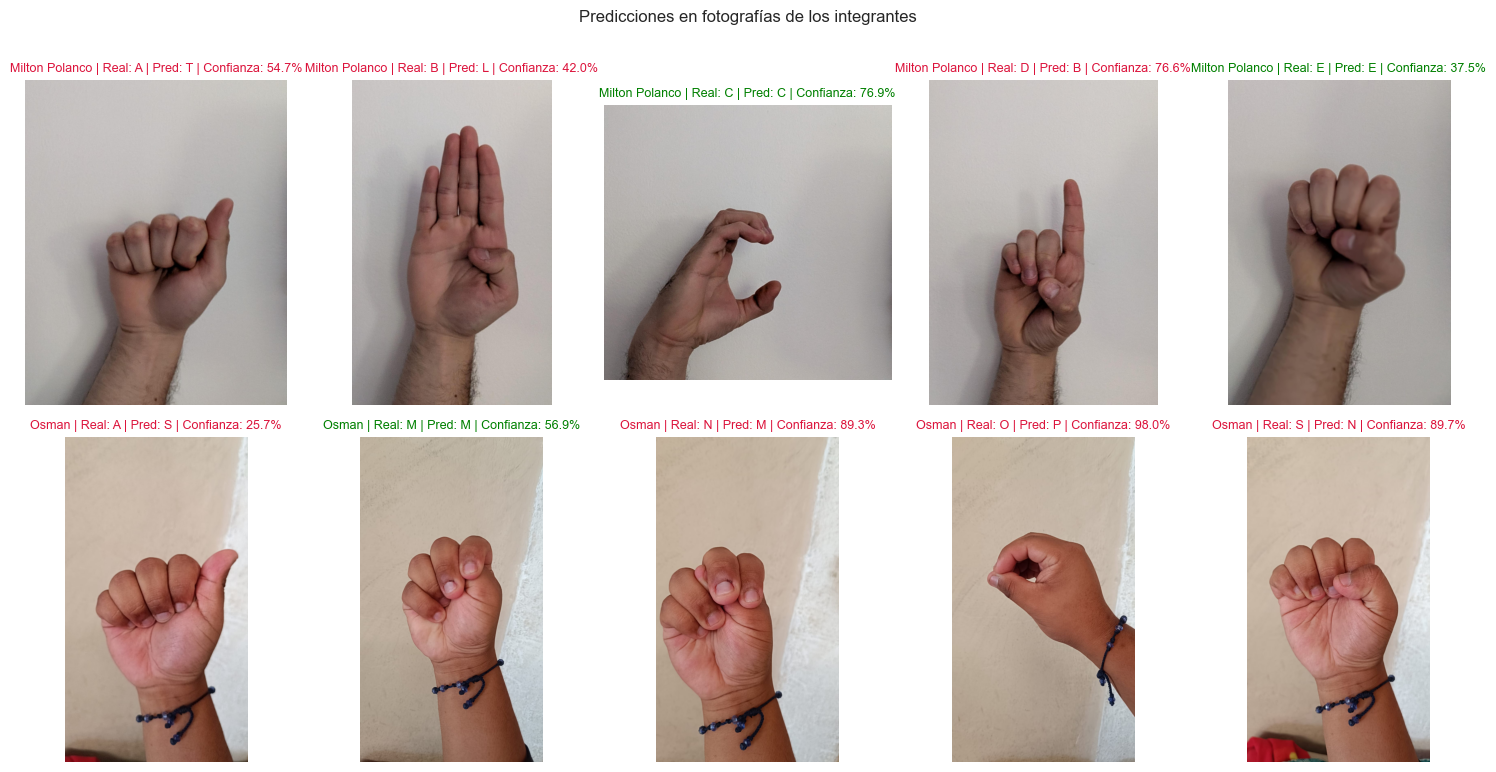

In [34]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image, ImageOps
from IPython.display import display

# Se reutiliza el modelo seleccionado y cargado en la sección anterior.
required_names = {"PROJECT_ROOT", "CLASSES", "IMAGE_SIZE", "best_model"}
missing_names = sorted(required_names.difference(globals()))
if missing_names:
    raise RuntimeError(
        "Ejecute primero las secciones anteriores del notebook. Faltan: "
        + ", ".join(missing_names)
    )
image_extensions = {".jpg", ".jpeg", ".png"}

OWN_IMAGES_DIR = PROJECT_ROOT / "own_images"
own_rows = []
image_arrays = []

for participant_dir in sorted(p for p in OWN_IMAGES_DIR.iterdir() if p.is_dir()):
    for path in sorted(participant_dir.iterdir()):
        if path.suffix.lower() not in image_extensions:
            continue
        true_name = path.stem.split("_")[0]
        if true_name not in CLASSES:
            print(f"Se omite {path.name}: la clase no se reconoce en el nombre.")
            continue
        with Image.open(path) as image:
            image = ImageOps.exif_transpose(image).convert("RGB")
            array = np.asarray(image.resize(IMAGE_SIZE), dtype=np.float32) / 255.0
        own_rows.append({
            "integrante": participant_dir.name,
            "archivo": path.name,
            "path": path,
            "real": true_name,
        })
        image_arrays.append(array)

own_df = pd.DataFrame(own_rows)
if own_df.empty:
    print("No se encontraron fotografías propias en", OWN_IMAGES_DIR)
else:
    distinct = own_df.groupby("integrante")["real"].nunique()
    if (distinct < 5).any():
        raise ValueError("Cada integrante debe aportar por lo menos cinco letras distintas.")

    probabilities = best_model.predict(np.stack(image_arrays), verbose=0)
    top_indices = np.argsort(probabilities, axis=1)[:, ::-1][:, :3]
    own_df["predicha"] = [CLASSES[row[0]] for row in top_indices]
    own_df["confianza"] = [probabilities[i, row[0]] for i, row in enumerate(top_indices)]
    own_df["top_3"] = [
        ", ".join(f"{CLASSES[idx]} ({probabilities[i, idx]:.1%})" for idx in row)
        for i, row in enumerate(top_indices)
    ]
    own_df["correcta"] = own_df["real"] == own_df["predicha"]

    display(
        own_df.drop(columns="path").style.format({"confianza": "{:.1%}"})
    )

    own_summary = (
        own_df.groupby("integrante")["correcta"]
        .agg(aciertos="sum", fotos="count", accuracy="mean")
    )
    display(own_summary.style.format({"accuracy": "{:.1%}"}))
    print(
        f"Exactitud total en fotografías propias: "
        f"{own_df['correcta'].sum()}/{len(own_df)} = {own_df['correcta'].mean():.1%}"
    )

    cols = 5
    rows = int(np.ceil(len(own_df) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3.8 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, row in zip(axes, own_df.itertuples()):
        with Image.open(row.path) as image:
            ax.imshow(ImageOps.exif_transpose(image))
        color = "green" if row.correcta else "crimson"
        ax.set_title(
            f"{row.integrante} | Real: {row.real} | Pred: {row.predicha} | "
            f"Confianza: {row.confianza:.1%}",
            color=color,
            fontsize=9,
        )
        ax.axis("off")
    for ax in axes[len(own_df):]:
        ax.axis("off")
    plt.suptitle("Predicciones en fotografías de los integrantes", y=1.01)
    plt.tight_layout()
    plt.show()

### Resultado con fotografías propias

Se evaluaron cinco letras de Milton Polanco (A, B, C, D y E) y cinco de Osman (A, M, N, O y S). Milton acertó **2 de 5** (C y E), Osman acertó **1 de 5** (M) y la exactitud total fue **3 de 10, o 30 %**. Los errores fueron A→T, B→L y D→B para Milton; y A→S, N→M, O→P y S→N para Osman.

La caída desde 98 % en la prueba interna hasta 30 % con fotos propias es evidencia clara de **cambio de dominio**. Las fotografías reales tienen fondos claros, diferentes tonos de piel, cámaras, proporciones verticales, escalas y orientaciones que no están suficientemente representadas en Kaggle. La confusión N→M coincide con el grupo visualmente similar identificado en el EDA.

También se observaron predicciones incorrectas con confianza alta: N→M con 89.3 %, O→P con 98.0 % y S→N con 89.7 %. Por lo tanto, la salida `softmax` no puede tratarse como una probabilidad calibrada ni utilizarse sola para decidir que una predicción es segura. El resultado apoya la recomendación de recolectar datos más diversos, calibrar la confianza e incluir una opción de “no reconocido” antes de usar el prototipo como herramienta de accesibilidad.

# 12. Accesibilidad, sesgo y límites del prototipo

El dataset es grande y balanceado por etiqueta, pero su diversidad visual es limitada. Las imágenes parecen provenir de pocas condiciones de captura: fondo similar, distancia controlada y variaciones moderadas. No se documenta una distribución representativa de tonos de piel, edades, tamaños de mano, movilidad reducida, cámaras o ambientes de iluminación. Un sistema que funciona bien aquí puede fallar más con grupos poco representados.

También hay límites propios de la tarea. ASL no es un lenguaje universal y no equivale a LENSEGUA. Además, J y Z se expresan con movimiento; clasificarlas a partir de una sola fotografía elimina información temporal. Un traductor real necesita reconocer secuencias, expresiones faciales, orientación corporal y contexto lingüístico, no solamente letras aisladas.

Para acercar el prototipo a SignBridge haría falta:

1. recolectar datos con consentimiento de muchas personas y medir desempeño por tono de piel, mano dominante, tamaño de mano, dispositivo e iluminación;
2. separar entrenamiento y prueba por persona y sesión para medir generalización real;
3. usar video y un modelo temporal para señas con movimiento;
4. incorporar una opción de baja confianza o “no reconocido”, en vez de forzar siempre una letra;
5. probar la interfaz con personas sordas y especialistas en la lengua objetivo, incluyendo privacidad y procesamiento local cuando sea posible.

Una recomendación concreta para la siguiente iteración es realizar una prueba con participantes que no aparezcan en entrenamiento, en al menos tres condiciones de iluminación, y publicar F1 por subgrupo además del promedio. Eso permitiría detectar diferencias de desempeño antes de presentar el sistema como herramienta de accesibilidad.

# 13. Conclusiones

In [35]:
best_row = results_df.iloc[0]
best_family_rows = (
    results_df.sort_values("val_f1_macro", ascending=False)
    .groupby("familia", as_index=False)
    .first()
)
print(
    f"El modelo seleccionado fue {best_row['modelo']} con "
    f"F1 macro de validación {best_row['val_f1_macro']:.4f} y "
    f"F1 macro de prueba {best_row['test_f1_macro']:.4f}."
)
display(best_family_rows[["familia", "modelo", "val_f1_macro", "test_f1_macro"]])

El modelo seleccionado fue cnn_improved con F1 macro de validación 0.9807 y F1 macro de prueba 0.9800.


,familia,modelo,val_f1_macro,test_f1_macro
0,CNN,cnn_improved,0.980721,0.980024
1,CNN + augmentation,cnn_improved_aug,0.957450,0.960534
2,Fully connected,fc_regularized,0.381038,0.386614
3,Random Forest,rf_unrestricted,0.961341,0.967767


La arquitectura seleccionada fue la **CNN mejorada sin augmentation**, con F1 macro de validación de **0.9807** y F1 macro de prueba de **0.9800**. Superó a Random Forest (0.9678 en prueba) y a la red densa regularizada (0.3866), lo que respalda el uso de convoluciones para aprovechar la estructura espacial de las manos. La CNN base demostró que no cualquier red convolucional es suficiente: su F1 de 0.2099 quedó incluso por debajo de la red densa ajustada.

El augmentation evaluado no mejoró el desempeño con el número de épocas disponible, por lo que no se seleccionó esa versión. Los errores internos del mejor modelo se concentraron sobre todo en S/X, U/X y W/V. Aunque alcanzó 98 % en la prueba interna y 28/28 en la pequeña prueba oficial, solo acertó **3 de 10 fotos propias**: 2/5 de Milton y 1/5 de Osman.

Esta diferencia es el hallazgo más importante para SignBridge. El modelo reconoce muy bien imágenes parecidas a Kaggle, pero no generaliza de forma confiable a nuevas personas, fondos y cámaras. En consecuencia, este trabajo debe considerarse un prototipo de clasificación estática, no un traductor listo para usuarios. Para avanzar se necesitan datos diversos recolectados por persona y sesión, evaluación por subgrupos, calibración de confianza y video para las señas que dependen del movimiento.